In [ ]:
from __future__ import annotations

import operator
from typing import Annotated, List, Literal, TypedDict

from pydantic import BaseModel, Field
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send

from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.tools.tavily_search import TavilySearchTool


In [ ]:
#schemas
class Task(BaseModel):
    id:int
    title:str

    goal:str=Field(
        ...,
        description="A detailed description of the task, including any relevant information that may help in completing the task."
    )

    bullets:List[str]=Field(
        ...,
        min_length=3,
        max_length=5,
        description="A list of bullet points that provide additional details or instructions related to the task."
    )

    target_words:int=Field(
        ...,
        description="The target number of words for the task. This can be used to guide the length of the response or output generated for the task."
    )

    tags:List[str]=Field(default_factory=list)
    requires_research:bool=False
    requires_citations:bool=False
    requires_code:bool=False

    class Plan(BaseModel):
        blog_title: str
        audience:str
        tone: str
        blog_kind:Literal["explainer","titorial","news_roundup","comparison","system_design"]="explainer"
        constraints:List[str]=Field(default_factory=list)
        tasks:List[Task]

    class EvidenceItem(BaseModel):
        title:str
        url:str
        published_at=Optional[str]=None
        snippet:Optional[str]=None
        source:Optional[str]=None

    class RouteDecision(BaseModel):
        needs_research:bool=False
        node:Literal["closed_book","hybrid","open_book"]
        queries:List[str]=Field(default_factory=list)

    class EvidencePack(BaseModel):
        evidence:List[EvidenceItem]=Field(default_factory=list)
        


In [ ]:
class State(TypedDict):
    topic: str

    #route
    node:str
    needs_research:bool
    queries:List[str]
    evidence:List[EvidenceItem]
    plan:Optional[Plan]

    #workers
    sections:Annonated[List[tuple[int,str]], operator.add]
    final:str

   

In [46]:
llm = ChatNVIDIA(model="nvidia/nemotron-3-nano-30b-a3b")

In [ ]:
ROUTER_SYSTEM=""" you are a routing module for a technical blog planner .
Decide wheather web search is needed BEFORE planning

modes:
- closed_book: rely solely on your internal knowledge to create a plan for the blog post. Do not perform any web search. This mode is suitable when the topic is well-known and you have sufficient information to create a comprehensive plan without external resources.
- hybrid: perform a web search to gather additional information and insights about the topic, but also rely on your internal knowledge to create the plan. This mode is suitable when the topic is somewhat familiar but may require some additional research to create a comprehensive plan.
- open_book: perform an extensive web
 search to gather as much information as possible about the topic, and use that information to create a detailed and comprehensive plan. This mode is suitable when the topic is unfamiliar or complex, and requires a significant amount of research to create an effective plan.

If needs research=true:
-output 3-10 high-signal queries.
-queries should bee stopped and specific .
-If user asked for "last  week/This week/latest" , reflect that constraint IN THE QUESRIES.
"""

def router_node(state:State)->dict:
    topic: state["topic"]
    decider: llm.with_structured_output(RouterDecision)
    decision=decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic:{topic}"),

        ]
    )

    return {
        "needs_research":decision.needs_research,
        "node":decision.node,
        "queries":decision.queries,
    }

def route_next(state:State)->str:
    return "research" if state ["needs_research"] else "orchestrator"
    



In [ ]:
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized

RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""
def research_node(state: State) -> dict:

    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])
    max_results = 6

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

# Deduplicate by URL
dedup={}
for e in pack.evidence :
    if e .url:
        dedup[e.url]=e
    return {"evidence": list(dedup.values())}


In [ ]:
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""
def orchestrator_node(state:State)->dict:
    planner=llm.with_structured_output(Plan)
    

    evidence=state.get("evidence",[])
    mode=state.get("mode", "closed_book")

    plan=planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=
                f"topic: {state['topic']}\n"
                f"mode: {mode}\n\n"
                f"Evidence:\n"
                f"{[e.model_dump() for e in evidence ][:16]}"

            )
        ]
    )

    return {"plan":plan}

In [48]:
def fanout(state: State):
    return [
        Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
        for task in state["plan"].tasks
    ]

In [49]:
def _fallback_section(topic: str, task: Task, plan: Plan) -> str:
    bullet_lines = "\n".join(f"- {b}" for b in task.bullets)
    return (
        f"## {task.title}\n\n"
        f"{task.brief}\n\n"
        f"Audience: {plan.audience}\n\n"
        f"Tone: {plan.tone}\n\n"
        f"{task.goal}\n\n"
        f"{bullet_lines}\n"
    )


def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    try:
        section_md = llm.invoke(
            [
                SystemMessage(
                    content=f"write a detailed markdown for the following section: {task.title} on the topic {topic} with the brief {task.brief}"
                ),
                HumanMessage(
                    content=(
                        f"blog: {blog_title}\n"
                        f"topic: {topic}\n\n"
                        f"section: {task.title}\n\n"
                        f"brief: {task.brief}\n\n"
                        f"audience: {plan.audience}\n\n"
                        f"tone: {plan.tone}\n\n"
                        f"goal: {task.goal}\n\n"
                        f"bullets: {task.bullets}\n\n"
                        f"target_words: {task.target_words}\n\n"
                        "return only the section content in markdown"
                    )
                ),
            ]
        ).content.strip()
    except Exception:
        section_md = _fallback_section(topic, task, plan)

    return {"sections": [section_md]}

In [50]:
from pathlib import Path


def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [51]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout)
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

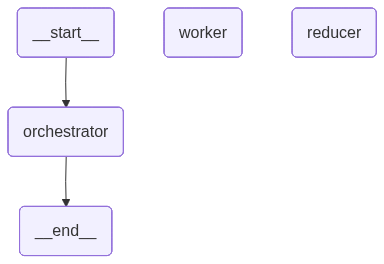

In [52]:
app

In [53]:
out = app.invoke({"topic": "wrote a blog on self attention", "sections": []})
